# PRINCIPLES OF FEATURE ENGINEERING



ESTABLISHING A BASELINE

A baseline is the simplest reasonable model you can build for a problem -- used as a model against which every more complex model must justify its existance, to prove it is actually learning anything and it isn't just complexity for its own sake.

A baseline score is that's system model performance on your chosen metrix (MEA, RMSE, etc)

# 1. MUTUAL INFORMATION

First step when encountering a new dataset is to construct a ranking with a FEATURE UTILITY METRIC, a function measuring associations between a feature and the target. 

The metric we'll use is called "mutual information". It can detect any relationship, while correlation (Pearson's r) only detects linear relationships.

DEFINITION:
Mutual information(MI) btw two random variables X and Y measures how much knowing the value of one reduces your uncertainty about the other. Formally, it is defined using __Shannon entropy__: 

                                             I(X;Y)=H(Y)− H(Y∣X)

- H(Y) is the entropy of Y on its own — how much uncertainty there is about Y before you know anything else.
- H(Y∣X) is the conditional entropy — how much uncertainty remains about Y once you already know X.
- The difference is exactly how much uncertainty X removes. If knowing X tells you nothing about Y, H(Y∣X)=H(Y) and I(X;Y)=0. If X fully determines Y, H(Y∣X)=0 and I(X;Y)=H(Y) — maximal.

The minimal MI btw quantities is 0.0, when they are independent. Conversely, in theory there is no upper bound to what MI can be, though in practice values above 2.0 are uncommon. (MI is a logarithmic quantity, so it increases very slowly)

Take into consideration:
- A feature can be very informative when interacting with other features, but not so informative all alone. MI can't detect interactions btw features. It is a __univariate__ metric
- The actual usefulness of a feature depends on the model you use it with. A feature is only useful to the extent that its relationship with the target is one your model can learn. Eventhough one may have a high MI, your model may not be able to handle that info so you must transform the feature to expose the association.







# 2.CREATING FEATURES


In [ ]:
#create a new column out of other multiple ones
autos["stroke_ratio"] = autos.stroke / autos.bore # type: ignore

#or
autos["displacement"] = np.pi * autos.bore  # type: ignore

In [ ]:
#data visualization can suggest transformations, often through powers and logarithms.
#if the feature has 0.0 values, use np.log1p() instead of np.log()
accidents["LogWingSpeed"] = accidents.WingSpeed.apply(np.log1p) # type: ignore

#plot a comparison
fig, axis = plt.subplots(1, 2, figsize=(8, 4)) 
sns.kdeplot(accidents.WingSpeed, shade=True, ax=axis[0]) 
sns.kdeplot(accidents.LogWingSpeed, shade=True, ax=axis[1])

COUNTS

Features describing the presence or absence of something ofter come in sets. You can aggregate such features by creating a __count__.

These features will be binary (1 for Present, 0 for Absent) or boolean. In Python, booleans can be added up.

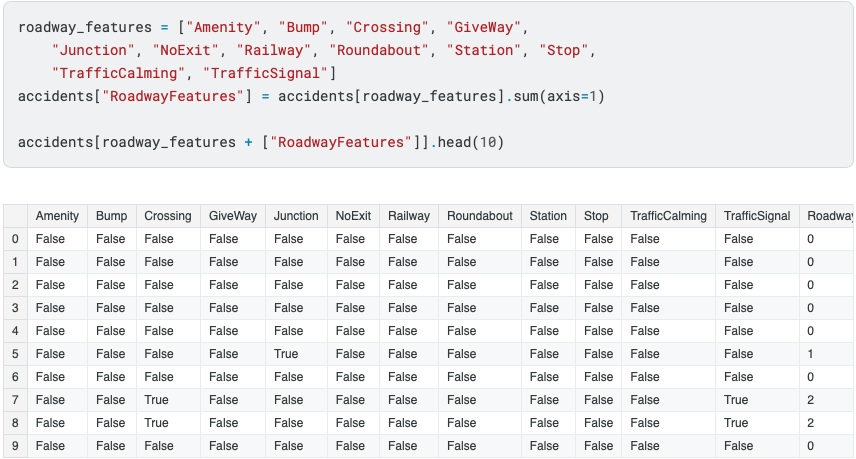

For DataFrames where it is stored the amounts of components for example, you can still count which are present, with the dataframe's built-in greater-than gt method

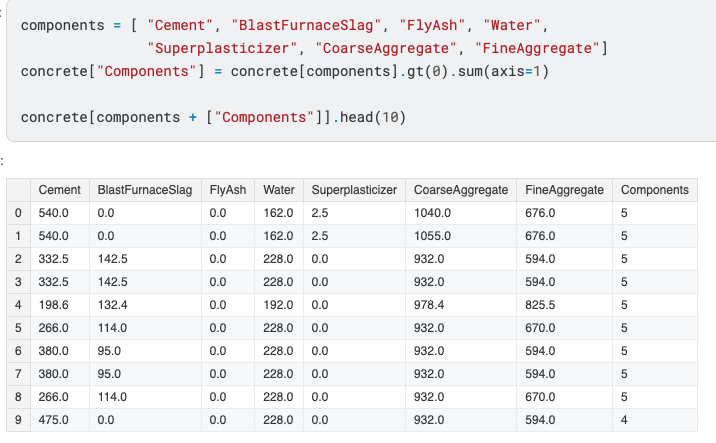

The str accessor lets you apply string methods like split directly to columns.

![Captura de pantalla 2026-09-07 a las 16.04.45.png](<attachment:Captura de pantalla 2026-09-07 a las 16.04.45.png>)

or join using +

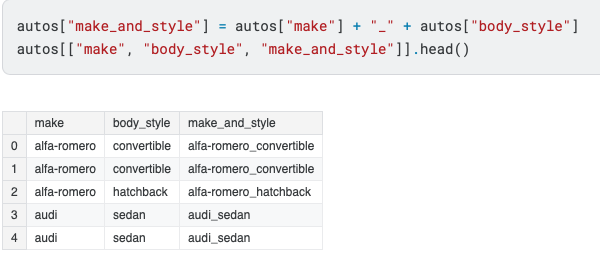
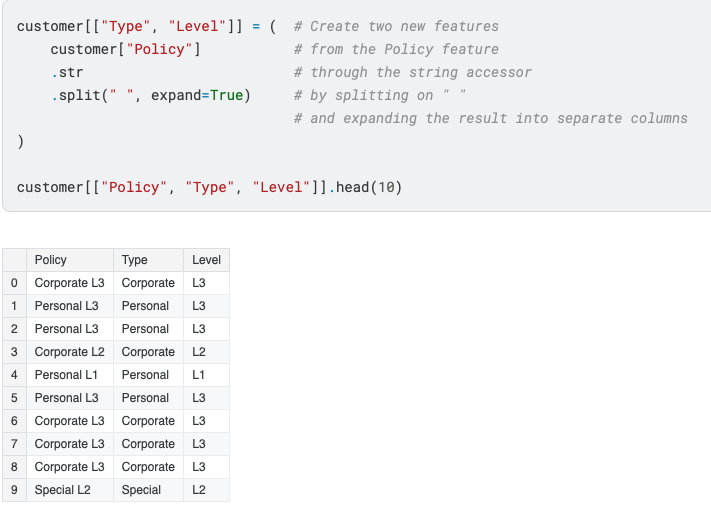

GROUP TRANSFORMS

Using an aggregation function, a group transform combines two features: 
- a categorical feature that porivdes the grouping 
- another feature whose values you wish to aggregate.

Ex: For an "average income by state", you would choose __State__ for the grouping feature, __mean__ for the aggregation function, and __Income__ for the aggregated feature.

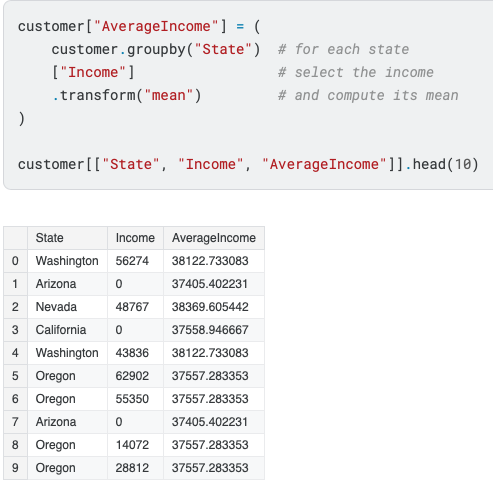

Other methods: max, min, median, var, str and count

Ex: How to calculate the frequency with which each state occurs in the dataset

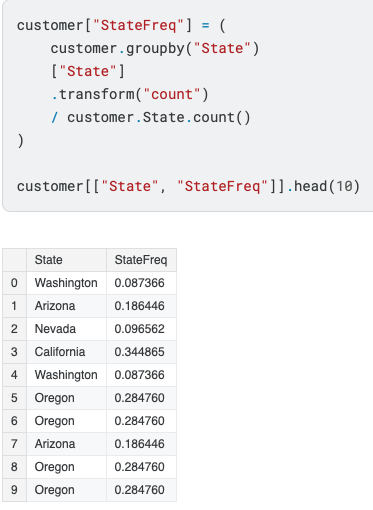